In [1]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using Statistics
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#15 (generic function with 1 method)

In [2]:
discount_factor=0.99
period = 1
graph=RVSDDP.InfiniteLinearGraph(period);

In [3]:
function subproblem_builder(subproblem::Model, node::Int, discount_factor::Float64)
    # State variables
    N=1
    @variable(subproblem, 0 <= volume[1:N] <= 200, RVSDDP.State, initial_value = 50)
    # Control variables
    @variables(subproblem, begin
        thermal_generation[1:4] >= 0
        thermal_generation_tot >= 0
        hydro_generation[1:N] >= 0
        hydro_spill[1:N] >= 0
        deficit >= 0
    end)
    # Random variables
    @variable(subproblem, inflow)
    Ω = [20.0, 80.0]
    # Ω = [40.0]
    P = [1 / length(Ω) for _ in Ω]
    # Ω = [70.0]
    # P = [1.0]
    RVSDDP.parameterize(subproblem, Ω, P) do ω
        return JuMP.fix(inflow, ω)
    end

    capa_th = [10 15 10 5] 
    c_th = [1 2 5 10]
    # Transition function and constraints
    @constraints(
        subproblem,
        begin
            [i in 1:N], volume[i].out == volume[i].in - hydro_generation[i] - hydro_spill[i] + inflow
            [i in 1:N], hydro_generation[i] <= 100
            [i in 1:1], thermal_generation[i] <= capa_th[i]
            thermal_generation_tot==sum(thermal_generation[i] for i in 1:4)
            deficit + sum(hydro_generation[i] for i in 1:N) + thermal_generation_tot == 60
        end
    )
    # Stage-objective
    @stageobjective(subproblem, 1*(50*sum(hydro_spill[i] for i in 1:N) + 50 * deficit+ sum(thermal_generation[i]*c_th[i] for i in 1:4)))
    return subproblem
end

subproblem_builder (generic function with 1 method)

In [4]:
graph = RVSDDP.LinearGraph(120);
model0 = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model0; refine_mode = 0, parallel=parallel, time_limit = 10, infinite = false, shift_function=RVSDDP.no_shift);

In [5]:
graph=RVSDDP.InfiniteLinearGraph(period);
model0 = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model0; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), time_limit = 10, infinite = true, shift_function=RVSDDP.no_shift); 

In [10]:
nb_cuts_list = [10, 40, 100, 200, 500]
V = Dict()
ind = 0:1:200
discount_factor=0.9
for cut_max in nb_cuts_list
    graph=RVSDDP.InfiniteLinearGraph(period);
    model0 = RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    )

    Random.seed!(1)
    parallel= 1
    Cuts0=RVSDDP.train(model0; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), cut_limit = cut_max, infinite = true, shift_function=RVSDDP.no_shift); 
    V[cut_max]=[RVSDDP.compute_V(model0[1].value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
end

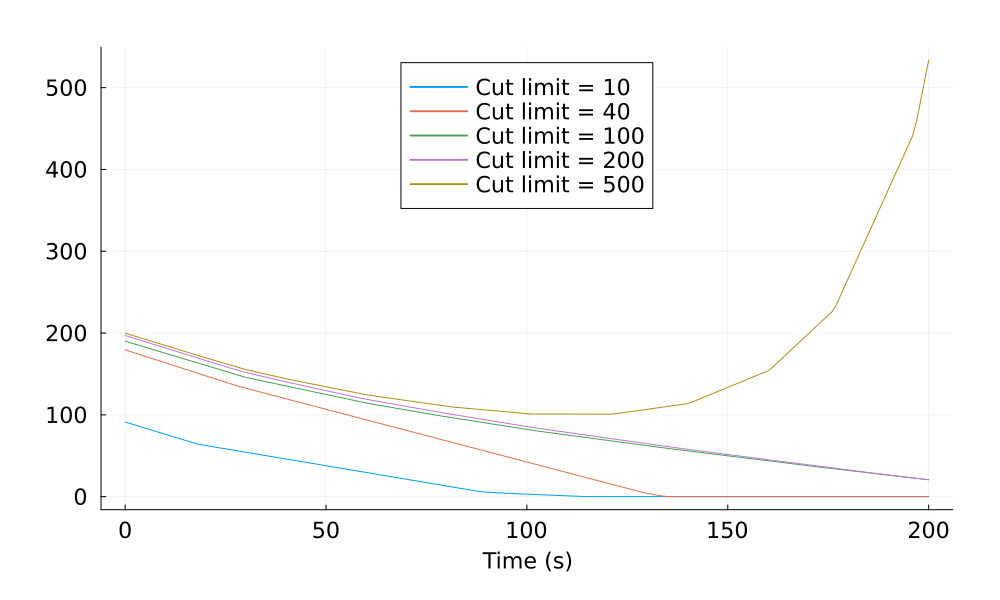

In [11]:
fontsize=15
p=plot(xlabel="Time (s)", guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, size=(1000, 600), margin=10Plots.mm, legend=:top)
for cut_max in nb_cuts_list
    plot!(ind, V[cut_max], label="Cut limit = $cut_max")
end
p